
# Оцінка та вдосконалення моделі


<h2>Мета</h2>

Ознайомитись з методами оцінки та вдосконалення регресійних моделей. Після завершення цієї лабораторної роботи ви зможете:

* Розділяти дані на навчальну та тестову вибірки
* Використовувати перехресну перевірку для оцінки якості моделі
* Обирати оптимальну складність моделі для уникнення перенавчання
* Вдосконалювати моделі прогнозування за допомогою підбору параметрів


<div class="alert alert-danger alertdanger" style="margin-top: 20px">

# <h1 id="task">Завдання, що оцінюються </h1>

</div>


1. Скачайте дані з фінального файлу першої роботи з виправленими помилками та заповненими пропусками. Запишіть дані у два датафрейми: предиктори (x_data) та відгуки (y_data). Випадковим чином розділіть дані на навчальні та тестові (використайте 20% загального набору в якості тестових даних).
2. Побудуйте модель лінійної одномірної регресії для одного з предикторів, використовуючи навчальні дані. Знайдіть R^2 на навчальних та тестових даних. Чому вони різні і на який з них треба орієнтуватись при виборі моделі?
3. Побудуйте кілька поліноміальних моделей різних ступенів для того ж предиктора. Знайдіть R^2 цих моделей на тестових даних. Яка з моделей краща? При якому ступені полінома спостерігається перенавчання?
4. Побудуйте модель гребеневої регресії для двох найкращих предикторів. Параметр alpha повинен бути встановлений на 10. Обчисліть R^2.
5. Виконайте пошук по сітці для параметра alpha та параметра нормалізації, а потім побудуйте модель, використавши найкращі значення параметрів.

<a name="task1"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task1">Завдання  #1: </h2>

<p>Запишіть дані у два датафрейми: предиктори (x_data) та відгуки (y_data). Випадковим чином розділіть дані на навчальні та тестові (використайте 20% загального набору в якості тестових даних).</p>
</div>


Зчитую дані з файлу у датафрейм


In [1]:
import pandas as pd
df = pd.read_csv('clean_data2.csv', encoding='utf-8', sep=',');
df = df.drop(columns=['Unnamed: 0']); # Видаляємо стовпець 'Unnamed: 0', який є індексом після збереження DataFrame у CSV
df.head(3)

,Country Name,Region,GDP per capita,Population,CO2 emission,Area,Population Density
0,Afghanistan,South Asia,561.778746,34656032.0,9809.225,652860.0,53.083405
1,Albania,Europe & Central Asia,4124.982390,2876101.0,5716.853,28750.0,100.038296
2,Algeria,Middle East & North Africa,3916.881571,40606052.0,145400.217,2381740.0,17.048902


Буду використовувати тільки числові дані


In [2]:
numeric_df = df.select_dtypes(include=['number']);
numeric_df.head(3)

,GDP per capita,Population,CO2 emission,Area,Population Density
0,561.778746,34656032.0,9809.225,652860.0,53.083405
1,4124.982390,2876101.0,5716.853,28750.0,100.038296
2,3916.881571,40606052.0,145400.217,2381740.0,17.048902


Записую дані у два датафрейми: предиктори (x_data) та відгуки (y_data).


In [3]:
y_data = numeric_df[['CO2 emission']]
x_data = numeric_df.drop('CO2 emission', axis=1)

Випадковим чином розділяю дані на навчальні та тестові (40% загального набору в якості тестових даних).


In [4]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.40, random_state=42)

print('Number of samples in test set:', len(x_test))
print('Number of samples in training set:', len(x_train))

Number of samples in test set: 87
Number of samples in training set: 130


<a name="task2"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task2">Завдання  #2: </h2>

<p>Побудуйте модель лінійної одномірної регресії для одного з предикторів, використовуючи навчальні дані. Знайдіть R^2 на навчальних та тестових даних. Чому вони різні і на який з них треба орієнтуватись при виборі моделі?</p>
</div>


<p>З попередніх робіт знаю, що хорошими показниками для 'CO2 emission' можуть бути:</p>
<ul>
    <li>Population</li>
    <li>Area</li>
</ul>
При цьому одномірна модель для ознаки 1 була кращою. Тому будуватиму моделі, використовуючи саме цю ознаку як предиктор.

<p>Створюю об’єкт лінійної регресії та навчаю модель</p>


In [5]:
from sklearn.linear_model import LinearRegression
modelOne = LinearRegression()
modelOne.fit(x_train[['Population']], y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Обчислюю R^2  на навчальних та тестових даних:


In [6]:
# Обчислюємо R^2 для навчальної вибірки
r2_train = modelOne.score(x_train[['Population']], y_train)
print('R^2 for training set:', r2_train)

# Обчислюємо R^2 для тестової вибірки
r2_test = modelOne.score(x_test[['Population']], y_test)
print('R^2 for test set:', r2_test)

R^2 for training set: 0.6195776028214226
R^2 for test set: 0.3582709219838224


<p style="color: #333; font-family: Arial, sans-serif; font-size: 16px;">
Вони різні, тому що модель навчалась на навчальній вибірці, яка відрізняється від тестової. У результаті вона краще підлаштувалась під тренувальні дані, але на нових (тестових) даних показує нижчу якість прогнозування.
</p>
<p style="color: #333; font-family: Arial, sans-serif; font-size: 16px;">
При виборі моделі треба орієнтуватись на значення R² для тестової вибірки, оскільки воно показує здатність моделі до узагальнення та якість прогнозування на нових даних.
</p>

<a name="task3"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task3">Завдання  #3: </h2>

<p>Побудуйте кілька поліноміальних моделей різних ступенів для того ж предиктора. Знайдіть R^2 цих моделей на тестових даних. Яка з моделей краща? При якому ступені полінома спостерігається перенавчання?</p>
</div>


Будую поліноміальну модель 2 ступеня, на тестових даних обчислюю R^2


In [ ]:
degrees = list(range(2, 5))
mse_list = []
r2_list = []

In [8]:
# Виконую поліноміальне перетворення 2 ступеня для ознаки 'Population'
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

poly1 = PolynomialFeatures(degree=2, include_bias=False)

x_train_poly1 = poly1.fit_transform(x_train[['Population']])
x_test_poly1 = poly1.transform(x_test[['Population']])

# Будую поліноміальну модель
modelTwo = LinearRegression()
modelTwo.fit(x_train_poly1, y_train)

# На навчальних даних обчислюю R^2
r2_train_two = modelTwo.score(x_train_poly1, y_train)
print('R^2 for training set (degree 2):', r2_train_two)

# На тестових даних обчислюю R^2
r2_two = modelTwo.score(x_test_poly1, y_test)
mse_two = mean_squared_error(y_test, modelTwo.predict(x_test_poly1))

r2_list.append(r2_two)
mse_list.append(mse_two)

print('R^2 for polynomial model (degree 2):', r2_two)
print('MSE for polynomial model (degree 2):', mse_two)

R^2 for training set (degree 2): 0.646681445484071
R^2 for polynomial model (degree 2): 0.3493404096795474
MSE for polynomial model (degree 2): 980467771942.5994


Будую поліноміальну модель 3 ступеня, на тестових даних обчислюю R^2


In [9]:
# Виконую поліноміальне перетворення 3 ступеня для ознаки 'Population'
poly2 = PolynomialFeatures(degree=3, include_bias=False)

x_train_poly2 = poly2.fit_transform(x_train[['Population']])
x_test_poly2 = poly2.transform(x_test[['Population']])

# Будую поліноміальну модель
modelThree = LinearRegression()
modelThree.fit(x_train_poly2, y_train)

# На навчальних даних обчислюю R^2
r2_train_three = modelThree.score(x_train_poly2, y_train)
print('R^2 for training set (degree 3):', r2_train_three)

# На тестових даних обчислюю R^2
r2_three = modelThree.score(x_test_poly2, y_test)
r2_list.append(r2_three)

mse_three = mean_squared_error(y_test, modelThree.predict(x_test_poly2))
mse_list.append(mse_three)

print('R^2 for polynomial model (degree 3):', r2_three)
print('MSE for polynomial model (degree 3):', mse_three)

R^2 for training set (degree 3): 0.5750837404290272
R^2 for polynomial model (degree 3): 0.2675035085180649
MSE for polynomial model (degree 3): 1103786394057.9941


Будую поліноміальну модель 4 ступеня, на тестових даних обчислюю R^2


In [10]:
# Виконую поліноміальне перетворення 4 ступеня для ознаки 'Population'
poly3 = PolynomialFeatures(degree=4, include_bias=False)

x_train_poly3 = poly3.fit_transform(x_train[['Population']])
x_test_poly3 = poly3.transform(x_test[['Population']])

# Будую поліноміальну модель
modelFour = LinearRegression()
modelFour.fit(x_train_poly3, y_train)

# На навчальних даних обчислюю R^2
r2_four_train = modelFour.score(x_train_poly3, y_train)
print('R^2 for polynomial model (degree 4) on training set:', r2_four_train)

# На тестових даних обчислюю R^2
r2_four = modelFour.score(x_test_poly3, y_test)
r2_list.append(r2_four)

mse_four = mean_squared_error(y_test, modelFour.predict(x_test_poly3))
mse_list.append(mse_four)

print('R^2 for polynomial model (degree 4):', r2_four)
print('MSE for polynomial model (degree 4):', mse_four)

R^2 for polynomial model (degree 4) on training set: 0.534876421432119
R^2 for polynomial model (degree 4): -0.2800508413391327
MSE for polynomial model (degree 4): 1928886648336.2097


Візуалізую моделі (зручно розміщувати всі моделі на одному графіку для обрання найкращої) та показник їх якості (доцільно побудувати графік залежності R^2 або MSE від порядку поліному моделі)

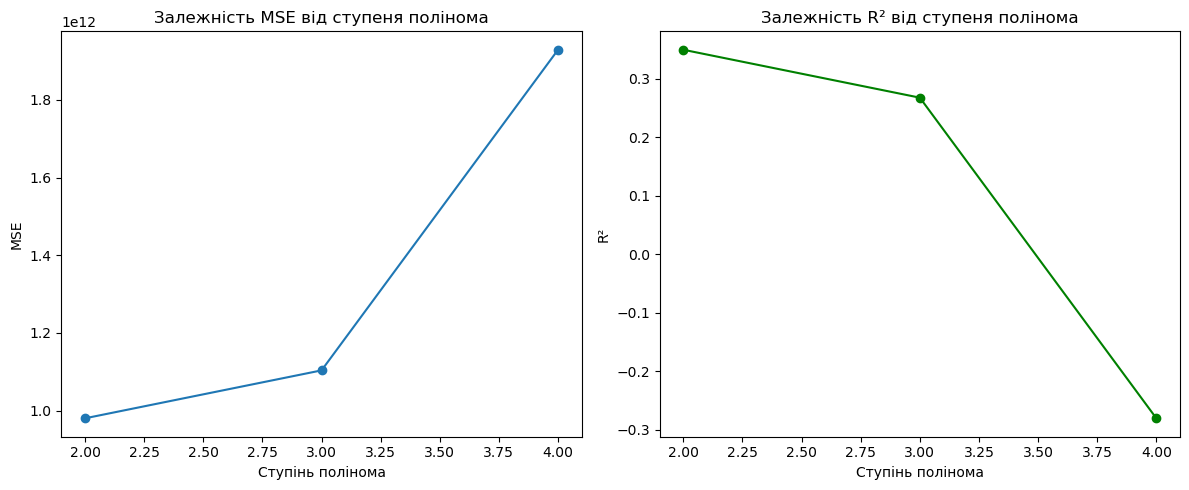

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(degrees, mse_list, marker='o')
plt.xlabel('Ступінь полінома')
plt.ylabel('MSE')
plt.title('Залежність MSE від ступеня полінома')

plt.subplot(1,2,2)
plt.plot(degrees, r2_list, marker='o', color='green')
plt.xlabel('Ступінь полінома')
plt.ylabel('R²')
plt.title('Залежність R² від ступеня полінома')

plt.tight_layout()
plt.show()

Найкращою є модель 2 ступеня, бо при збільшенні ступеня до 3 і 4 зменшується значення R^2 на тестовій вибірці та зростає MSE, що свідчить про перенавчання моделі.


<a name="task4"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task4">Завдання  #4: </h2>

<p>Побудуйте модель гребеневої регресії для двох найкращих предикторів. Параметр alpha повинен бути встановлений на 10. Обчисліть R^2.</p>
</div>


Будую модель гребеневої регресії, обчислюю R^2


R^2 train: 0.8199461952203762
MSE train: 13256295551.248465
R^2 test: 0.6273294643349197
MSE test: 561570835515.1417


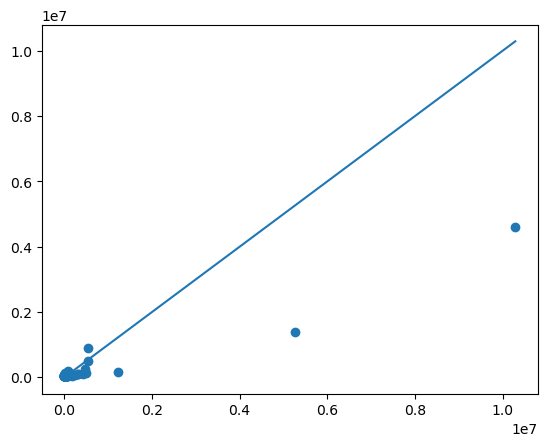

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

# Створюємо pipeline
model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)), # Виконую поліноміальне перетворення 2 ступеня для двох обраних ознак
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=10)) # Створюю об’єкт гребеневої регресії, встановивши параметр alpha=10
])

# Подібно до звичайної регресії будую модель за допомогою методу fit
model.fit(x_train[['Population', 'Area']], y_train)

y_train_pred = model.predict(x_train[['Population', 'Area']])
y_test_pred = model.predict(x_test[['Population', 'Area']])

print('R^2 train:', model.score(x_train[['Population', 'Area']], y_train))
print('MSE train:', mean_squared_error(y_train, y_train_pred))

print('R^2 test:', model.score(x_test[['Population', 'Area']], y_test))
print('MSE test:', mean_squared_error(y_test, y_test_pred))


plt.scatter(y_test, y_test_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])

<a name="task5"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task5">Завдання  #5: </h2>

<p>Виконайте пошук по сітці для параметра alpha та параметра нормалізації 🙃, а потім побудуйте модель, використавши найкращі значення параметрів.</p>
</div>


Створюю словник значень параметрів:


In [13]:
import numpy as np

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge', Ridge())
])

parameters = {
   'ridge__alpha': np.logspace(-4, 4, 30),
   'scaler': [StandardScaler(), 'passthrough']  # заміна normalize True / False
}

Створюю об’єкт сітки пошуку параметра гребеневої регресії:


In [14]:
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(pipe, parameters, cv=5, scoring='r2', n_jobs=-1)

Підбираю модель:


In [15]:
grid_search.fit(x_train[['Population', 'Area']], y_train)

,estimator,"Pipeline(step...e', Ridge())])"
,param_grid,"{'ridge__alpha': array([1.0000...00000000e+04]), 'scaler': [StandardScaler(), 'passthrough']}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


Отримую модель з найкращими параметрами:


In [16]:
best_model = grid_search.best_estimator_

Тестую модель на тестових даних (обчислюю R^2):


In [17]:
# R² на тренувальних даних
r2_train = best_model.score(x_train[['Population', 'Area']], y_train)
print('R^2 train:', r2_train)

# R² на тестових даних
r2_test = best_model.score(x_test[['Population', 'Area']], y_test)
print('R^2 test:', r2_test)

R^2 train: 0.7815761375620691
R^2 test: 0.5190841736224634


<a name="task6"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task6"> Додаткове завдання: </h2>

<p>Побудуйте візуалізації для оцінки якості моделей (лінійної, кращої з поліноміальних та кращої з гребеневих), всі розмістіть на одній координатній сітці для зручного порівняння.</p>
</div>


Використаю метод "predict", щоб спрогнозувати результати, а потім скористаюсь функцією "DistributionPlot", щоб відобразити розподіл прогнозованих результатів для тестових даних порівняно з фактичними для тестових даних.


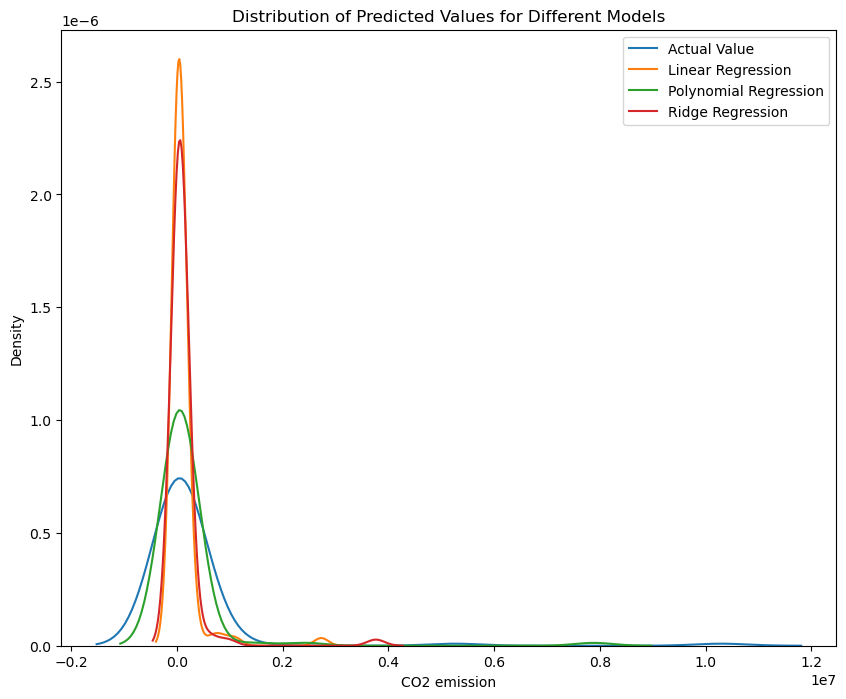

In [18]:
import seaborn as sns

linear_model = LinearRegression()
linear_model.fit(x_train[['Population', 'Area']], y_train)
y_test_predicted_linear = linear_model.predict(x_test[['Population', 'Area']])

poly_model_best = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('linear', LinearRegression())
])
poly_model_best.fit(x_train[['Population', 'Area']], y_train)

y_test_predicted_poly = poly_model_best.predict(x_test[['Population', 'Area']])
y_test_predicted_ridge = best_model.predict(x_test[['Population', 'Area']]) 

plt.figure(figsize=(10, 8)) 
sns.kdeplot(y_test, label="Actual Value") 
sns.kdeplot(y_test_predicted_linear.squeeze(), label="Linear Regression") 
sns.kdeplot(y_test_predicted_poly.squeeze(), label="Polynomial Regression")
sns.kdeplot(y_test_predicted_ridge.squeeze(), label="Ridge Regression") 
plt.xlabel("CO2 emission") 
plt.ylabel("Density") 
plt.title("Distribution of Predicted Values for Different Models") 
plt.legend() 
plt.show()

<h4>Висновок</h4>

<p>Порівнюючи всі моделі, роблю висновок, що <b>модель Ridge Regression є найкращою моделлю</b> для прогнозування 'CO2 emission' на основі нашого набору даних, оскільки вона забезпечує найбільш стабільний та узагальнений розподіл передбачень без значних викидів, на відміну від поліноміальної моделі, яка демонструє ознаки перенавчання.</p>

<h2>Виконав студент групи ІП-45 <br> Буряк Володимир</h2>
